In [1]:
import numpy as np
import pandas as pd
import os

In [28]:
os.listdir('train_data')

['.ipynb_checkpoints',
 'train_1.csv',
 'train_10.csv',
 'train_11.csv',
 'train_12.csv',
 'train_13.csv',
 'train_14.csv',
 'train_15.csv',
 'train_2.csv',
 'train_3.csv',
 'train_4.csv',
 'train_5.csv',
 'train_6.csv',
 'train_7.csv',
 'train_8.csv',
 'train_9.csv']

In [32]:
paths = ['train_data', 'val_data', 'test_data']
for path in paths:
    lens = []
    for inner in os.listdir(path):
        if inner == '.ipynb_checkpoints':
            continue
        read = pd.read_csv(os.path.join(path,inner))
        lens.append(len(read))

    minimum = min(lens)

    if path == 'train_data':
        print(f'batch size for training: {minimum}')
    elif path == 'val_data':
        print(f'batch size for validation: {minimum}')
    else:
        print(f'batch size for test: {minimum}')

    cropped_df = []
    for inner in os.listdir(path):
        if inner == '.ipynb_checkpoints':
            continue
        read = pd.read_csv(os.path.join(path,inner))
        read = read[:minimum]
        cropped_df.append(read)
        read.to_csv(os.path.join(path,inner),index=False)
        
    concat_df = pd.concat(cropped_df,axis=0,ignore_index=True)
    concat_df.to_csv(path+'_joined.csv',index=False)

batch size for training: 10034
batch size for validation: 10034
batch size for test: 10034


In [48]:
common_batch_size = 10034

In [33]:
train_df = pd.read_csv('train_data_joined.csv')
train_df.head()

,time,V,IC,IL,IR,R,L,C,vs
0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,10,0.2,0.02,0.5
1,1.000000e-09,2.500000e-12,0.000050,1.251250e-20,-0.000050,10,0.2,0.02,0.5
2,1.024000e-09,2.561440e-12,0.000051,1.282018e-20,-0.000051,10,0.2,0.02,0.5
3,1.072000e-09,2.687200e-12,0.000054,1.345064e-20,-0.000054,10,0.2,0.02,0.5
4,1.168000e-09,2.956000e-12,0.000058,1.480636e-20,-0.000058,10,0.2,0.02,0.5


In [34]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150510 entries, 0 to 150509
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    150510 non-null  float64
 1   V       150510 non-null  float64
 2   IC      150510 non-null  float64
 3   IL      150510 non-null  float64
 4   IR      150510 non-null  float64
 5   R       150510 non-null  int64  
 6   L       150510 non-null  float64
 7   C       150510 non-null  float64
 8   vs      150510 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 10.3 MB


In [36]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
time,150510.0,0.498250,0.289647,0.000000,0.247387,0.498248,0.749082,1.000000
V,150510.0,0.062481,0.180458,-0.237209,-0.036357,0.011130,0.122265,0.967192
IC,150510.0,-0.000969,0.029065,-0.080885,-0.010347,-0.000005,0.008021,0.150000
IL,150510.0,0.052540,0.053955,0.000000,0.012844,0.034030,0.069367,0.222912
IR,150510.0,-0.051570,0.043590,-0.173721,-0.082858,-0.038273,-0.015123,0.000000
R,150510.0,36.000000,33.226606,10.000000,10.000000,30.000000,30.000000,100.000000
L,150510.0,2.040000,2.481621,0.200000,0.500000,1.000000,3.000000,10.000000
C,150510.0,0.020100,0.016615,0.000500,0.010000,0.020000,0.020000,0.050000
vs,150510.0,1.000000,0.408250,0.500000,0.500000,1.000000,1.500000,1.500000


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

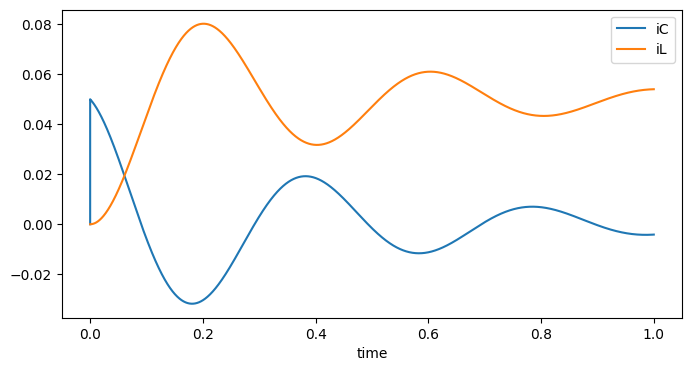

In [38]:
example = train_df[train_df['R'].eq(10) & train_df['L'].eq(0.2) & train_df['C'].eq(0.02)]

plt.figure(figsize=(8,4))
plt.plot(example['time'], example['IC'], label='iC')
plt.plot(example['time'], example['IL'], label='iL')
plt.xlabel('time')
plt.legend()
plt.show()

<Axes: >

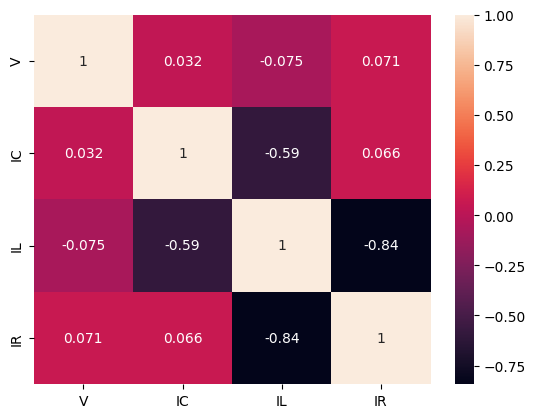

In [40]:
df_corr = train_df[['V','IC','IL','IR']].corr()
sns.heatmap(df_corr, annot=True)

In [41]:
val_df = pd.read_csv('val_data_joined.csv')
val_df.head()

,time,V,IC,IL,IR,R,L,C,vs
0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,10,0.3,0.03,0.5
1,1.000000e-09,1.666667e-12,0.000050,5.561111e-21,-0.000050,10,0.3,0.03,0.5
2,1.024000e-09,1.707627e-12,0.000051,5.697857e-21,-0.000051,10,0.3,0.03,0.5
3,1.072000e-09,1.791467e-12,0.000054,5.978064e-21,-0.000054,10,0.3,0.03,0.5
4,1.168000e-09,1.970666e-12,0.000058,6.580603e-21,-0.000058,10,0.3,0.03,0.5


In [43]:
test_df = pd.read_csv('test_data_joined.csv')
test_df.head()

,time,V,IC,IL,IR,R,L,C,vs
0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,10,0.2,0.01,1.0
1,1.000000e-09,9.999999e-12,0.000100,5.004999e-20,-0.000100,10,0.2,0.01,1.0
2,1.024000e-09,1.024576e-11,0.000102,5.128072e-20,-0.000102,10,0.2,0.01,1.0
3,1.072000e-09,1.074880e-11,0.000107,5.380258e-20,-0.000107,10,0.2,0.01,1.0
4,1.168000e-09,1.182400e-11,0.000117,5.922543e-20,-0.000117,10,0.2,0.01,1.0


In [45]:
features = ['time','R','L','C','vs']
outputs = ['IC','IL']

In [46]:
xtrain = train_df[features]
ytrain = train_df[outputs]

xval = val_df[features]
yval = val_df[outputs]

xtest = test_df[features]
ytest = test_df[outputs]

In [47]:
xtrain

,time,R,L,C,vs
0,0.000000e+00,10,0.2,0.02,0.5
1,1.000000e-09,10,0.2,0.02,0.5
2,1.024000e-09,10,0.2,0.02,0.5
3,1.072000e-09,10,0.2,0.02,0.5
4,1.168000e-09,10,0.2,0.02,0.5
...,...,...,...,...,...
150505,9.994046e-01,30,3.0,0.01,1.5
150506,9.995046e-01,30,3.0,0.01,1.5
150507,9.996046e-01,30,3.0,0.01,1.5
150508,9.997046e-01,30,3.0,0.01,1.5


In [49]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

In [52]:
xtrain = scaler.fit_transform(xtrain)
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

In [54]:
ytrain

,IC,IL
0,0.000000,0.000000e+00
1,0.000050,1.251250e-20
2,0.000051,1.282018e-20
3,0.000054,1.345064e-20
4,0.000058,1.480636e-20
...,...,...
150505,0.008820,4.510012e-02
150506,0.008821,4.509620e-02
150507,0.008822,4.509228e-02
150508,0.008823,4.508837e-02


In [53]:
import torch

In [58]:
xtrain = torch.tensor(xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain.values, dtype=torch.float32)

xval = torch.tensor(xval, dtype=torch.float32)
yval = torch.tensor(yval.values, dtype=torch.float32)
                     
xtest = torch.tensor(xtest, dtype=torch.float32)
ytest = torch.tensor(ytest.values, dtype=torch.float32)


C:\Users\Abhishek\AppData\Local\Temp\ipykernel_21420\1397029519.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xtrain = torch.tensor(xtrain, dtype=torch.float32)


In [59]:
from torch.utils.data import TensorDataset, DataLoader

In [60]:
train_data = TensorDataset(xtrain,ytrain)
val_data = TensorDataset(xval,yval)
test_data = TensorDataset(xtest,ytest)

In [61]:
train_loader = DataLoader(train_data, batch_size=common_batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=common_batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=common_batch_size, shuffle=False)

In [63]:
xtrain.shape

torch.Size([150510, 5])

In [75]:
time_mean = scaler.mean_[0]
time_std = scaler.scale_[0]

In [76]:
t_mean = torch.tensor(time_mean, dtype=torch.float32, device='cuda')
t_std  = torch.tensor(time_std,  dtype=torch.float32, device='cuda')

In [77]:
from torch.autograd import grad

In [183]:
def physics_loss(model, x, t_std, t_col=0, R_col=1, L_col=2, C_col=3, Vs_col=4,return_residuals=False, phys_step=4):

    # Optionally subsample points used for physics residuals
    if phys_step is not None and phys_step > 1:
        idx = torch.arange(0, x.shape[0], step=phys_step, device=x.device)
        x_req = x[idx].clone()
    else:
        x_req = x.clone()

    x_req.requires_grad_(True)

    pred = model(x_req)          # [N_phys, 2]
    iC_pred = pred[:, 0:1]
    iL_pred = pred[:, 1:2]

    t_scaled = x_req[:, t_col:t_col+1]
    R = x_req[:, R_col:R_col+1]
    L = x_req[:, L_col:L_col+1]
    C = x_req[:, C_col:C_col+1]
    Vs = x_req[:, Vs_col:Vs_col+1]

    # ensure tensor
    if not torch.is_tensor(t_std):
        t_std_t = torch.tensor(t_std, dtype=x_req.dtype, device=x_req.device)
    else:
        t_std_t = t_std.to(device=x_req.device, dtype=x_req.dtype)

    # ---- diL/dt ----
    grad_iL_wrt_x, = torch.autograd.grad(
        outputs=iL_pred,
        inputs=x_req,
        grad_outputs=torch.ones_like(iL_pred),
        create_graph=True,
        retain_graph=True
    )
    diL_dts = grad_iL_wrt_x[:, t_col:t_col+1]
    diL_dt = diL_dts / t_std_t

    v_pred = L * diL_dt

    # ---- dv/dt ----
    grad_v_wrt_x, = torch.autograd.grad(
        outputs=v_pred,
        inputs=x_req,
        grad_outputs=torch.ones_like(v_pred),
        create_graph=True
    )
    dv_dts = grad_v_wrt_x[:, t_col:t_col+1]
    dv_dt = dv_dts / t_std_t

    iC_phys = C * dv_dt

    iR_pred = (v_pred - Vs) / R
    kcl_res = iC_pred + iL_pred + iR_pred       # should be 0
    cap_res = iC_pred - iC_phys                 # should be 0

    mse = torch.nn.MSELoss()
    loss_kcl = mse(kcl_res, torch.zeros_like(kcl_res))
    loss_cap = mse(cap_res, torch.zeros_like(cap_res))
    total_phys_loss = loss_kcl + loss_cap

    if return_residuals:
        return total_phys_loss, kcl_res, cap_res
    else:
        return total_phys_loss

In [184]:
lambda_phys_start = 0.01
lambda_phys_end   = 1.0

In [185]:
import torch.nn as nn
import torch.nn.functional as f

In [186]:
class solver(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(5, 64),
            nn.Tanh(),
            nn.Linear(64,32),
            nn.Tanh(),
            nn.Linear(32,15),
            nn.Tanh(),
            nn.Linear(15,2)
        )

    def forward(self, x):
        out = self.network(x)

        return out

In [187]:
model = solver()
model.cuda()

solver(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=15, bias=True)
    (5): Tanh()
    (6): Linear(in_features=15, out_features=2, bias=True)
  )
)

In [188]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [189]:
epochs = 300

In [190]:
train_loss = []
val_loss = []

for i in range(epochs):
    # Linear ramp for lambda_phys over epochs
    lambda_phys = lambda_phys_start + (lambda_phys_end - lambda_phys_start) * (i / max(epochs - 1, 1))

    model.train()
    n = 0
    train_batch_loss = []

    for batch, (x, y) in enumerate(train_loader):
        n += 1
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        pred = model(x)
        mse_loss = criterion(pred, y)
        phys_loss = physics_loss(model, x, t_std, phys_step=4)

        losses = mse_loss + lambda_phys * phys_loss
        losses.backward()
        optimizer.step()

        train_batch_loss.append(losses.item())

    train_loss.append(sum(train_batch_loss) / n)

    # Validation: data loss only, as before
    model.eval()
    n = 0
    val_batch_loss = []
    with torch.no_grad():
        for batch, (x, y) in enumerate(val_loader):
            n += 1
            x = x.cuda()
            y = y.cuda()
            pred = model(x)
            losses = criterion(pred, y)
            val_batch_loss.append(losses.item())

    val_loss.append(sum(val_batch_loss) / n)

    print(f'epoch {i+1}, lambda_phys: {lambda_phys:.4f}, '
          f'train_loss: {train_loss[-1]}, val_loss: {val_loss[-1]}')

epoch 1, lambda_phys: 0.0100, train_loss: 0.1353640377521515, val_loss: 0.008179613226093351
epoch 2, lambda_phys: 0.0133, train_loss: 0.16594363550345104, val_loss: 0.0085939597687684
epoch 3, lambda_phys: 0.0166, train_loss: 0.19987583458423613, val_loss: 0.012610409781336785
epoch 4, lambda_phys: 0.0199, train_loss: 0.22544775704542797, val_loss: 0.01644022261025384
epoch 5, lambda_phys: 0.0232, train_loss: 0.22898347079753875, val_loss: 0.025598974560853093
epoch 6, lambda_phys: 0.0266, train_loss: 0.2073511113723119, val_loss: 0.03998844679445028
epoch 7, lambda_phys: 0.0299, train_loss: 0.18021557827790577, val_loss: 0.042012730590067805
epoch 8, lambda_phys: 0.0332, train_loss: 0.1708667516708374, val_loss: 0.041579512297175825
epoch 9, lambda_phys: 0.0365, train_loss: 0.16550848384698233, val_loss: 0.039994257339276376
epoch 10, lambda_phys: 0.0398, train_loss: 0.16270899375279743, val_loss: 0.0431032498832792
epoch 11, lambda_phys: 0.0431, train_loss: 0.15965508321921032, val_

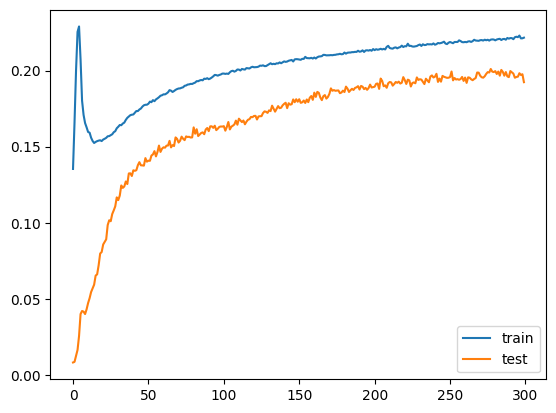

In [191]:
plt.plot(range(epochs),train_loss,label='train')
plt.plot(range(epochs),val_loss, label='test')
plt.legend()

In [192]:
model.eval()
with torch.no_grad():
    test_batch_loss=[]
    for batch,(x,y) in enumerate(test_loader):
        n+=1
        x = x.cuda()
        y = y.cuda()
        pred = model(x)
        losses = criterion(pred,y)
        test_batch_loss.append(losses.item())
pinn_final_loss = sum(test_batch_loss)/n
pinn_final_loss

0.22964280067632595

In [170]:
baseline = solver()
baseline.cuda()

solver(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=15, bias=True)
    (5): Tanh()
    (6): Linear(in_features=15, out_features=2, bias=True)
  )
)

In [171]:
criterion = nn.MSELoss()
optimizer= torch.optim.Adam(baseline.parameters(), lr=0.001)
epochs = 20

In [172]:
train_loss=[]
val_loss=[]

for i in range(epochs):
    n=0
    baseline.train()
    train_batch_loss=[]
    for batch,(x,y) in enumerate(train_loader):
        n+=1
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        pred = baseline(x)
        losses = criterion(pred,y)
        
        losses.backward()
        optimizer.step()

        train_batch_loss.append(losses.item())
    train_loss.append(sum(train_batch_loss)/n)

    baseline.eval()
    n=0
    val_batch_loss=[]
    with torch.no_grad():
        for batch,(x,y) in enumerate(val_loader):
            n+=1
            x = x.cuda()
            y = y.cuda()
            pred = baseline(x)
            losses = criterion(pred,y)
            
            val_batch_loss.append(losses.item())
    val_loss.append(sum(val_batch_loss)/n)

    print(f'epoch {i+1}, train_loss: {train_loss[-1]}, val_loss: {val_loss[-1]}')

epoch 1, train_loss: 0.009130693009744088, val_loss: 0.0036516240215860307
epoch 2, train_loss: 0.002055620355531573, val_loss: 0.0012441269267583267
epoch 3, train_loss: 0.0013171277474611997, val_loss: 0.0011951029206102247
epoch 4, train_loss: 0.0010843634993458787, val_loss: 0.001037510295282118
epoch 5, train_loss: 0.0009949504397809505, val_loss: 0.0010177037154790014
epoch 6, train_loss: 0.0009343198966234922, val_loss: 0.0009597385080269305
epoch 7, train_loss: 0.000882867316249758, val_loss: 0.0009266468667192384
epoch 8, train_loss: 0.0008353259724875291, val_loss: 0.0008801378076896072
epoch 9, train_loss: 0.0007901172580507894, val_loss: 0.0008459539505565772
epoch 10, train_loss: 0.0007477792329154909, val_loss: 0.0008085623167062295
epoch 11, train_loss: 0.0007071725325658917, val_loss: 0.0007740177174127893
epoch 12, train_loss: 0.0006694133626297116, val_loss: 0.0007345578074819059
epoch 13, train_loss: 0.0006332770261603097, val_loss: 0.0007017636557065998
epoch 14, tr

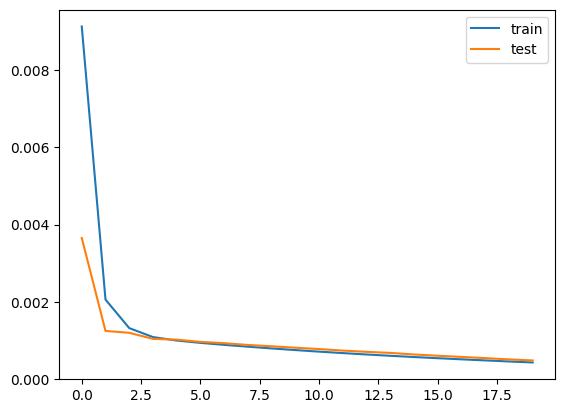

In [173]:
plt.plot(range(epochs),train_loss,label='train')
plt.plot(range(epochs),val_loss, label='test')
plt.legend()

In [174]:
baseline.eval()
with torch.no_grad():
    test_batch_loss=[]
    for batch,(x,y) in enumerate(test_loader):
        n+=1
        x = x.cuda()
        y = y.cuda()
        pred = baseline(x)
        losses = criterion(pred,y)
        test_batch_loss.append(losses.item())
base_final_loss = sum(test_batch_loss)/n
base_final_loss

0.00015775408489086354

In [195]:
def evaluate_residuals(model, df_test, x_scaler, t_std,
                       R_val, L_val, C_val,
                       device='cuda'):

    # 1. Select one trajectory by R, L, C
    traj_df = df_test[
        (df_test['R'] == R_val) &
        (df_test['L'] == L_val) &
        (df_test['C'] == C_val)
    ].copy()

    if len(traj_df) == 0:
        print("No trajectory found with R, L, C =", R_val, L_val, C_val)
        return

    # 2. Build inputs exactly as in training
    feat_cols = ['time', 'R', 'L', 'C', 'vs']
    X_raw = traj_df[feat_cols].values
    X_scaled = x_scaler.transform(X_raw)

    x = torch.tensor(X_scaled, dtype=torch.float32, device=device)

    # 3. Get predictions and residuals
    model.eval()
    with torch.no_grad():
        pred = model(x)
    # physics_loss needs a graph for grads, so call it WITHOUT no_grad:
    _, kcl_res_t, cap_res_t = physics_loss(
        model, x, t_std, return_residuals=True,phys_step=1)

    # 4. Move everything to numpy
    time_np = traj_df['time'].values
    iC_true = traj_df['IC'].values
    iL_true = traj_df['IL'].values

    iC_pred = pred[:, 0].detach().cpu().numpy()
    iL_pred = pred[:, 1].detach().cpu().numpy()

    kcl_res = kcl_res_t.detach().cpu().numpy().flatten()
    cap_res = cap_res_t.detach().cpu().numpy().flatten()

    # 5. Plot currents and residuals
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Currents
    axes[0].plot(time_np, iC_true, 'b--', label='True iC', alpha=0.7)
    axes[0].plot(time_np, iC_pred, 'b-',  label='Pred iC')
    axes[0].plot(time_np, iL_true, 'r--', label='True iL', alpha=0.7)
    axes[0].plot(time_np, iL_pred, 'r-',  label='Pred iL')
    axes[0].set_title(f"Currents (R={R_val}, L={L_val}, C={C_val})")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("current")
    axes[0].legend()

    # KCL residual
    axes[1].plot(time_np, kcl_res, 'k-')
    axes[1].axhline(0, color='gray', linestyle='--')
    axes[1].set_title("KCL residual (iC + iL + iR)")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("error")

    # Capacitor residual
    axes[2].plot(time_np, cap_res, 'm-')
    axes[2].axhline(0, color='gray', linestyle='--')
    axes[2].set_title("Capacitor residual (iC_pred - C dv/dt)")
    axes[2].set_xlabel("time")
    axes[2].set_ylabel("error")

    plt.tight_layout()
    plt.show()

    print(f"Mean |KCL|: {np.mean(np.abs(kcl_res)):.6e}")
    print(f"Mean |Cap|: {np.mean(np.abs(cap_res)):.6e}")

C:\Users\Abhishek\Vision course\dl-gpu-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


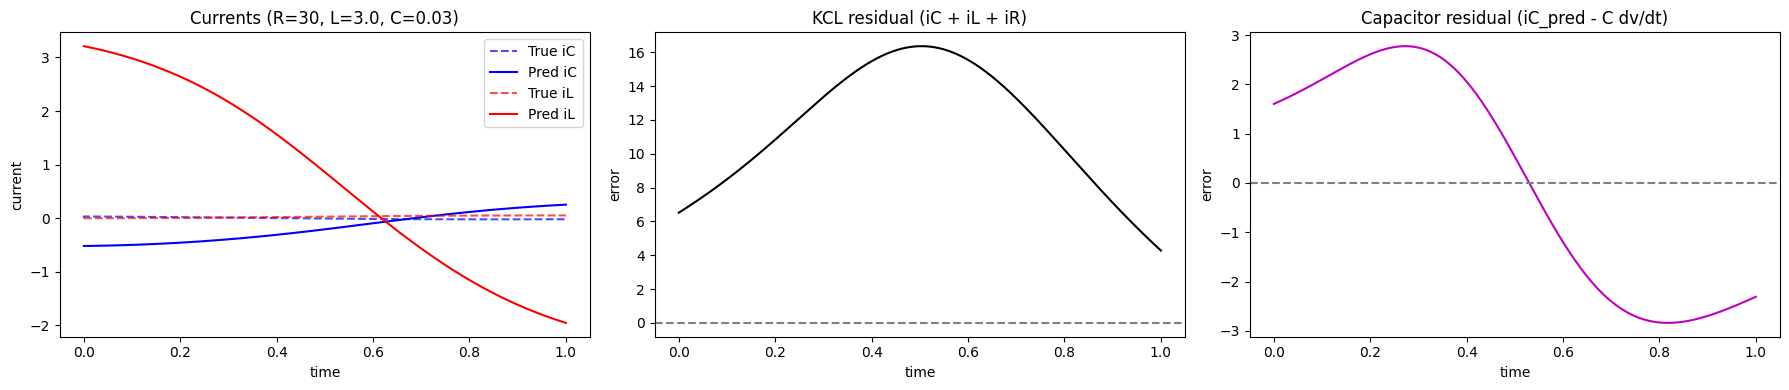

Mean |KCL|: 1.162855e+01
Mean |Cap|: 2.110638e+00


In [196]:
evaluate_residuals(
    model=model,
    df_test=test_df,
    x_scaler=scaler,
    t_std=t_std,
    R_val=30, L_val=3.0, C_val=0.03, 
    device='cuda'
)

C:\Users\Abhishek\Vision course\dl-gpu-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


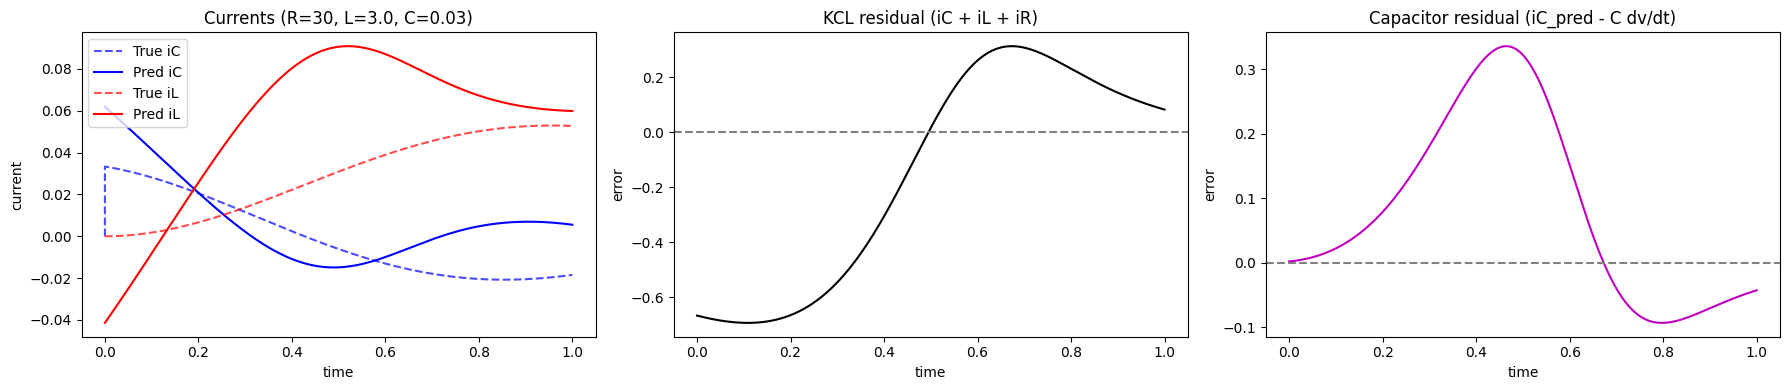

Mean |KCL|: 3.602630e-01
Mean |Cap|: 1.271669e-01


In [197]:
evaluate_residuals(
    model=baseline,
    df_test=test_df,
    x_scaler=scaler,
    t_std=t_std,
    R_val=30, L_val=3.0, C_val=0.03,
    device='cuda'
)